In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score 
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('cars24_data.csv')
df

,name,make,model,city,year,fueltype,kilometerdriven,ownernumber,transmission,bodytype,storename,isc24assured,registrationcity,registrationstate,benefits,discountprice,price,url,createdDate
0,Hyundai Elite i20,Hyundai,Elite I20,Kochi,2017,Petrol,35939,2,Manual,Hatchback,Kochi-Pns,False,Kozhikode,Kerala,13898,47399,607000,https://www.cars24.com/buy-used-hyundai-elite-...,2022-03-24
1,Maruti Alto 800,Maruti,Alto 800,Mumbai,2016,Petrol + Cng,6180,1,Manual,Hatchback,Hi-West Mumbai,False,Mumbai,Maharashtra,12542,2099,326000,https://www.cars24.com/buy-used-maruti-alto-80...,2022-11-09
2,Maruti Dzire,Maruti,Dzire,Lucknow,2019,Petrol + Cng,46808,1,Manual,Sedan,Vibhuti Khand - Gomti Nagar,False,Lucknow,Uttar Pradesh,13898,26000,640000,https://www.cars24.com/buy-used-maruti-dzire-2...,2022-09-30
3,KIA SELTOS,Kia,Seltos,Bangalore,2020,Diesel,26045,1,Manual,SUV,Bengaluru-Pns,False,Bengaluru,Karnataka,9688,143700,1354000,https://www.cars24.com/buy-used-kia-seltos-202...,2022-07-04
4,Maruti Ertiga,Maruti,Ertiga,Kolkata,2017,Petrol,53056,1,Manual,SUV,Hi-Kolkata,False,Barrackpore,West Bengal,13898,22800,676000,https://www.cars24.com/buy-used-maruti-ertiga-...,2022-10-28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6432,Mahindra XUV500,Mahindra,Xuv500,Hyderabad,2013,Diesel,74570,2,Manual,SUV,Hi-West Hyd,False,Hyderabad,Telangana,9688,0,744000,https://www.cars24.com/buy-used-mahindra-xuv50...,2022-12-09
6433,Renault Kwid,Renault,Kwid,Chandigarh,2017,Petrol,39981,2,Manual,Hatchback,Chandigarh-Pns,False,Faridabad,Haryana,12542,0,248000,https://www.cars24.com/buy-used-renault-kwid-2...,2022-12-10
6434,Hyundai i10,Hyundai,I10,Hyderabad,2014,Petrol,61249,1,Manual,Hatchback,Hi-West 2 Hyd,False,Hyderabad,Telangana,13898,0,351000,https://www.cars24.com/buy-used-hyundai-i10-20...,2022-12-10
6435,Maruti Swift Dzire,Maruti,Swift Dzire,Hyderabad,2014,Petrol,48081,1,Manual,Sedan,Hi-West 2 Hyd,False,Hyderabad,Telangana,13898,0,494000,https://www.cars24.com/buy-used-maruti-swift-d...,2022-12-10


In [3]:
# Shape of the data
df.shape

(6437, 19)

In [4]:
# Size of the data
df.size

122303

In [5]:
# Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6437 entries, 0 to 6436
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   name               6437 non-null   object
 1   make               6437 non-null   object
 2   model              6437 non-null   object
 3   city               6437 non-null   object
 4   year               6437 non-null   int64 
 5   fueltype           6437 non-null   object
 6   kilometerdriven    6437 non-null   int64 
 7   ownernumber        6437 non-null   int64 
 8   transmission       6061 non-null   object
 9   bodytype           6062 non-null   object
 10  storename          6437 non-null   object
 11  isc24assured       6437 non-null   bool  
 12  registrationcity   6437 non-null   object
 13  registrationstate  6437 non-null   object
 14  benefits           6437 non-null   int64 
 15  discountprice      6437 non-null   int64 
 16  price              6437 non-null   int64 


In [6]:
# Missing values
df.isnull().sum()

name                   0
make                   0
model                  0
city                   0
year                   0
fueltype               0
kilometerdriven        0
ownernumber            0
transmission         376
bodytype             375
storename              0
isc24assured           0
registrationcity       0
registrationstate      0
benefits               0
discountprice          0
price                  0
url                    0
createdDate            0
dtype: int64

In [7]:
# Handling missing values using imputation
df['transmission'].fillna(df['transmission'].mode()[0],inplace=True)
df['bodytype'].fillna(df['bodytype'].mode()[0],inplace=True)
df.isnull().sum()

name                 0
make                 0
model                0
city                 0
year                 0
fueltype             0
kilometerdriven      0
ownernumber          0
transmission         0
bodytype             0
storename            0
isc24assured         0
registrationcity     0
registrationstate    0
benefits             0
discountprice        0
price                0
url                  0
createdDate          0
dtype: int64

In [8]:
# Checking Duplicates
df.duplicated().sum()

np.int64(15)

In [9]:
# Removing Duplicates
df.drop_duplicates(inplace=True,ignore_index=True)
df.duplicated().sum()

np.int64(0)

In [10]:
# Analysis of Numerical columns and Categorical columns
num_df=df.select_dtypes(include='number')
print('===Numerical Columns===\n',num_df)
cat_df=df.select_dtypes(include='object')
print('===Numerical Columns===\n',cat_df)

===Numerical Columns===
       year  kilometerdriven  ownernumber  benefits  discountprice    price
0     2017            35939            2     13898          47399   607000
1     2016             6180            1     12542           2099   326000
2     2019            46808            1     13898          26000   640000
3     2020            26045            1      9688         143700  1354000
4     2017            53056            1     13898          22800   676000
...    ...              ...          ...       ...            ...      ...
6417  2013            74570            2      9688              0   744000
6418  2017            39981            2     12542              0   248000
6419  2014            61249            1     13898              0   351000
6420  2014            48081            1     13898              0   494000
6421  2019            54490            1     12542              0   371000

[6422 rows x 6 columns]
===Numerical Columns===
                     name 

In [11]:
# Summary statistics
print('==Statistical Summary==')
df.describe()

==Statistical Summary==


,year,kilometerdriven,ownernumber,benefits,discountprice,price
count,6422.000000,6422.000000,6422.000000,6422.000000,6422.000000,6.422000e+03
mean,2017.636718,41585.697291,1.235752,12081.752102,23553.318904,6.781921e+05
std,2.657746,26194.619845,0.454617,2459.171545,41609.748768,3.451704e+05
min,2008.000000,64.000000,1.000000,9688.000000,-155500.000000,1.340000e+05
25%,2016.000000,20617.000000,1.000000,9688.000000,-100.000000,4.390000e+05
50%,2018.000000,38205.000000,1.000000,12542.000000,10650.000000,5.880000e+05
75%,2020.000000,59359.750000,1.000000,13898.000000,37075.000000,8.290000e+05
max,2022.000000,455601.000000,3.000000,19407.000000,388300.000000,3.048000e+06


In [12]:
# Removed irrelevant and high-cardinality columns to simplify the dataset, reduce dimensionality, and ensure efficient encoding and model performance.
df.drop(columns=['name','model','storename','url','registrationcity','registrationstate'],inplace=True)

In [13]:
#Checking Negative discounted value and removing negative discount value
df['discountprice'] = df['discountprice'].clip(lower=0)

In [14]:
df['createdDate'] = pd.to_datetime(df['createdDate'])

In [15]:
#Calculaing the age of the car
df['car_age'] =df['createdDate'].dt.year-df['year']
df = df.drop(['createdDate'], axis=1)

In [16]:
df

,make,city,year,fueltype,kilometerdriven,ownernumber,transmission,bodytype,isc24assured,benefits,discountprice,price,car_age
0,Hyundai,Kochi,2017,Petrol,35939,2,Manual,Hatchback,False,13898,47399,607000,5
1,Maruti,Mumbai,2016,Petrol + Cng,6180,1,Manual,Hatchback,False,12542,2099,326000,6
2,Maruti,Lucknow,2019,Petrol + Cng,46808,1,Manual,Sedan,False,13898,26000,640000,3
3,Kia,Bangalore,2020,Diesel,26045,1,Manual,SUV,False,9688,143700,1354000,2
4,Maruti,Kolkata,2017,Petrol,53056,1,Manual,SUV,False,13898,22800,676000,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6417,Mahindra,Hyderabad,2013,Diesel,74570,2,Manual,SUV,False,9688,0,744000,9
6418,Renault,Chandigarh,2017,Petrol,39981,2,Manual,Hatchback,False,12542,0,248000,5
6419,Hyundai,Hyderabad,2014,Petrol,61249,1,Manual,Hatchback,False,13898,0,351000,8
6420,Maruti,Hyderabad,2014,Petrol,48081,1,Manual,Sedan,False,13898,0,494000,8


# Visualization

Text(0.5, 1.0, 'Price Distribution of Cars')

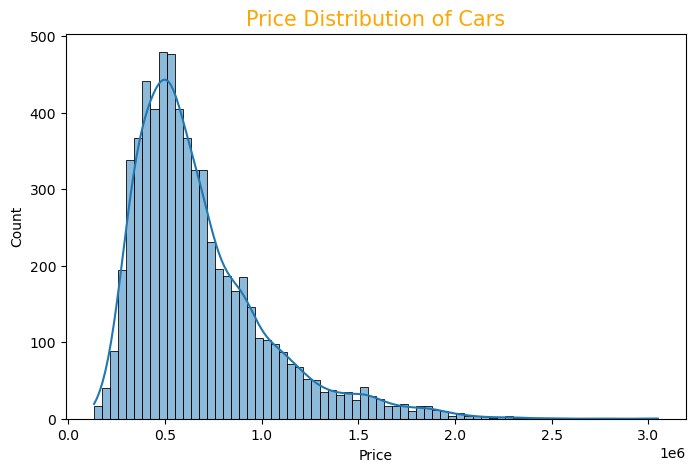

In [17]:
# Histogram
plt.figure(figsize=(8,5))
sns.histplot(df['price'],kde=True)
plt.xlabel('Price')
plt.ylabel('Count')
plt.title("Price Distribution of Cars",fontsize=15,color='orange')

Text(0.5, 1.0, 'Fuel Type Distribution using count plot')

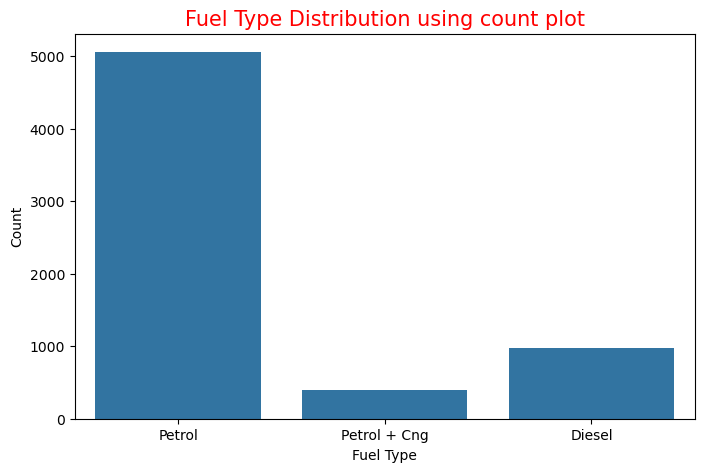

In [18]:
# Countplot
plt.figure(figsize=(8,5))
sns.countplot(x='fueltype',data=df)
plt.xlabel('Fuel Type')
plt.ylabel('Count')
plt.title('Fuel Type Distribution using count plot',fontsize=15,color='red')

Text(0.5, 1.0, 'Fuel Type vs Car Price')

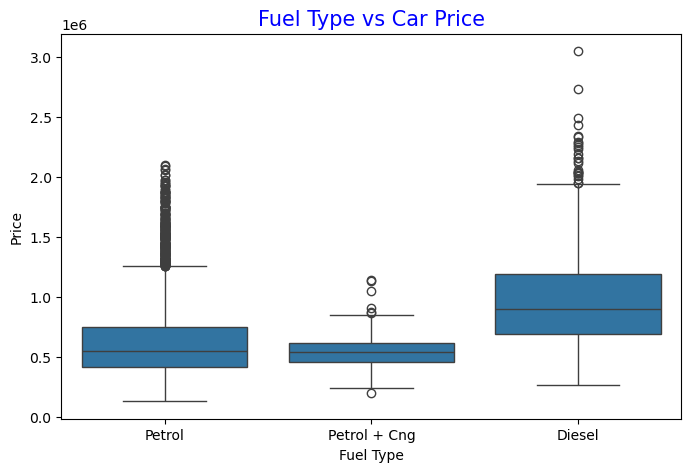

In [19]:
# Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x='fueltype',y='price',data=df)
plt.xlabel('Fuel Type')
plt.ylabel('Price')
plt.title('Fuel Type vs Car Price',fontsize=15,color='blue')

Text(0.5, 1.0, 'Price vs Kilometers Driven')

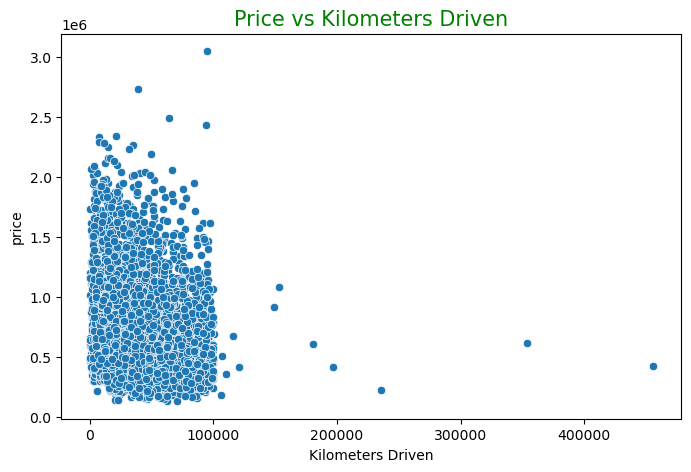

In [20]:
# Scatter plot
plt.figure(figsize=(8,5))
sns.scatterplot(x='kilometerdriven',y='price',data=df)
plt.xlabel('Kilometers Driven')
plt.ylabel('price')
plt.title('Price vs Kilometers Driven',fontsize=15,color='green')

Text(0.5, 1.0, 'Correlation Heatmap')

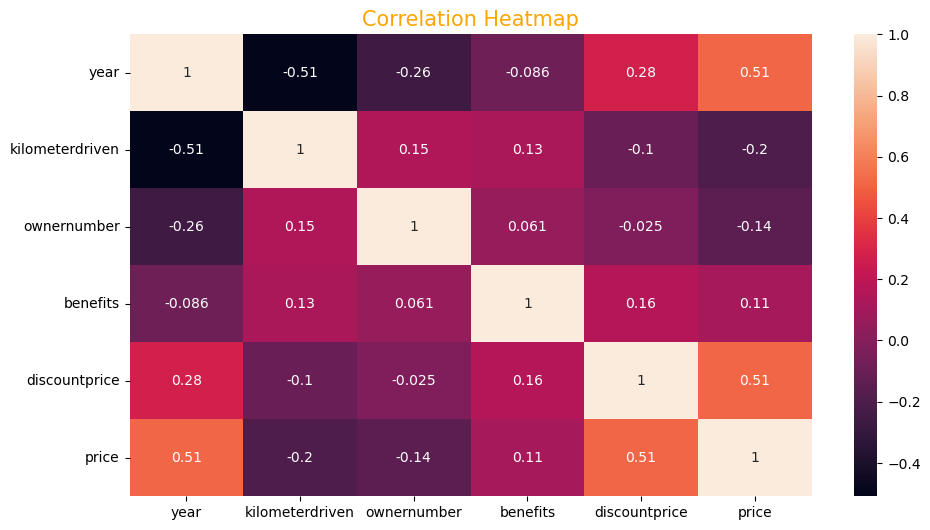

In [21]:
# Correlation heatmap
plt.figure(figsize=(11,6))
sns.heatmap(num_df.corr(),annot=True)
plt.title('Correlation Heatmap',fontsize=15,color='Orange')

In [22]:
df.head()

,make,city,year,fueltype,kilometerdriven,ownernumber,transmission,bodytype,isc24assured,benefits,discountprice,price,car_age
0,Hyundai,Kochi,2017,Petrol,35939,2,Manual,Hatchback,False,13898,47399,607000,5
1,Maruti,Mumbai,2016,Petrol + Cng,6180,1,Manual,Hatchback,False,12542,2099,326000,6
2,Maruti,Lucknow,2019,Petrol + Cng,46808,1,Manual,Sedan,False,13898,26000,640000,3
3,Kia,Bangalore,2020,Diesel,26045,1,Manual,SUV,False,9688,143700,1354000,2
4,Maruti,Kolkata,2017,Petrol,53056,1,Manual,SUV,False,13898,22800,676000,5


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6422 entries, 0 to 6421
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   make             6422 non-null   object
 1   city             6422 non-null   object
 2   year             6422 non-null   int64 
 3   fueltype         6422 non-null   object
 4   kilometerdriven  6422 non-null   int64 
 5   ownernumber      6422 non-null   int64 
 6   transmission     6422 non-null   object
 7   bodytype         6422 non-null   object
 8   isc24assured     6422 non-null   bool  
 9   benefits         6422 non-null   int64 
 10  discountprice    6422 non-null   int64 
 11  price            6422 non-null   int64 
 12  car_age          6422 non-null   int64 
dtypes: bool(1), int64(7), object(5)
memory usage: 608.5+ KB


In [24]:
df.head

<bound method NDFrame.head of           make        city  year      fueltype  kilometerdriven  ownernumber  \
0      Hyundai       Kochi  2017        Petrol            35939            2   
1       Maruti      Mumbai  2016  Petrol + Cng             6180            1   
2       Maruti     Lucknow  2019  Petrol + Cng            46808            1   
3          Kia   Bangalore  2020        Diesel            26045            1   
4       Maruti     Kolkata  2017        Petrol            53056            1   
...        ...         ...   ...           ...              ...          ...   
6417  Mahindra   Hyderabad  2013        Diesel            74570            2   
6418   Renault  Chandigarh  2017        Petrol            39981            2   
6419   Hyundai   Hyderabad  2014        Petrol            61249            1   
6420    Maruti   Hyderabad  2014        Petrol            48081            1   
6421   Renault   Hyderabad  2019        Petrol            54490            1   

     tran

<Axes: >

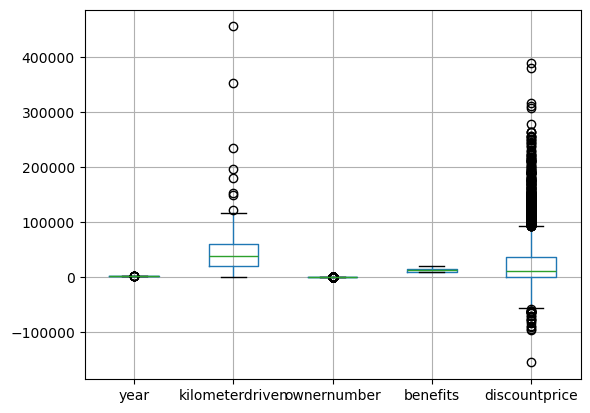

In [25]:
# Finding Outliers 
num_features=num_df.drop(columns='price')
num_features.boxplot()

In [26]:
# Oulier Capping
def outlier_capping(df,columns):
    Q1=df[columns].quantile(0.25)
    Q3=df[columns].quantile(0.75)
    IQR=Q3-Q1
    Lower_Extreme=Q1-1.5*IQR
    Upper_Extreme=Q3+1.5*IQR
    df[columns]=df[columns].apply(lambda x:Lower_Extreme if x<Lower_Extreme else Upper_Extreme if x>Upper_Extreme else x)
for col in num_features.select_dtypes(['int','float']).columns:
    outlier_capping(num_features,col)
#Updating original dataframe (df) with capped numerical features from num_features
df[num_features.columns] = num_features

<Axes: >

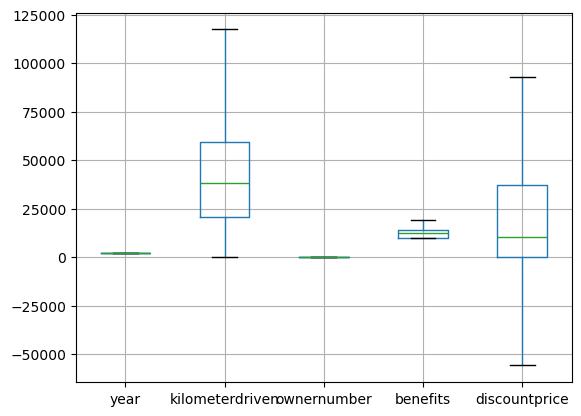

In [27]:
# After removing outliers
num_features.boxplot()

# Encoding the Categorical columns

In [28]:
from sklearn.preprocessing import TargetEncoder

In [29]:
df

,make,city,year,fueltype,kilometerdriven,ownernumber,transmission,bodytype,isc24assured,benefits,discountprice,price,car_age
0,Hyundai,Kochi,2017.0,Petrol,35939.0,1.0,Manual,Hatchback,False,13898,47399.0,607000,5
1,Maruti,Mumbai,2016.0,Petrol + Cng,6180.0,1.0,Manual,Hatchback,False,12542,2099.0,326000,6
2,Maruti,Lucknow,2019.0,Petrol + Cng,46808.0,1.0,Manual,Sedan,False,13898,26000.0,640000,3
3,Kia,Bangalore,2020.0,Diesel,26045.0,1.0,Manual,SUV,False,9688,92837.5,1354000,2
4,Maruti,Kolkata,2017.0,Petrol,53056.0,1.0,Manual,SUV,False,13898,22800.0,676000,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6417,Mahindra,Hyderabad,2013.0,Diesel,74570.0,1.0,Manual,SUV,False,9688,0.0,744000,9
6418,Renault,Chandigarh,2017.0,Petrol,39981.0,1.0,Manual,Hatchback,False,12542,0.0,248000,5
6419,Hyundai,Hyderabad,2014.0,Petrol,61249.0,1.0,Manual,Hatchback,False,13898,0.0,351000,8
6420,Maruti,Hyderabad,2014.0,Petrol,48081.0,1.0,Manual,Sedan,False,13898,0.0,494000,8


In [30]:
# One-hot -encoding for unordered categorical columns
df=pd.get_dummies(df,columns=['make','fueltype','transmission','bodytype','city'],drop_first=True).astype(int)
# Binary Encoding
df['isc24assured'] = df['isc24assured'].astype(int)

Since this is a regression problem and the dataset had already been cleaned and encoded with a manageable number of features, additional feature selection was not required.

# TrainTestSplit

In [31]:
# Seperating features and target
features=df.drop(columns='price')
target=df[['price']]

In [32]:
x_train,x_test,y_train,y_test=train_test_split(features,target,train_size=0.8,random_state=70)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(5137, 74)
(1285, 74)
(5137, 1)
(1285, 1)


In [33]:
#Scaling
scaler = StandardScaler() 

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Update X_train and X_test for subsequent model training to use the correctly scaled data
x_train = x_train_scaled
x_test = x_test_scaled

# Model Building

# Model 1:Linear Regression

In [34]:
lin_reg = LinearRegression()

In [35]:
lin_reg.fit(x_train,y_train)

LinearRegression()

In [36]:
# Predicted values
y_pred=lin_reg.predict(x_test)

In [37]:
r2_score_lr=r2_score(y_test,y_pred)
print("================Linear Regression================")
print('Mean Squared Error:', mean_squared_error(y_test, y_pred))
print('r2_score:',r2_score_lr)

================Linear Regression================
Mean Squared Error: 29794672833.894505
r2_score: 0.767964462751015


In [38]:
# Evaluation using training data
training_scr=lin_reg.score(x_train,y_train)
training_scr

0.7441670159352972

# Model 2: Random Forest

In [39]:
from sklearn.ensemble import RandomForestRegressor

In [40]:
# Model Training
rfm_model = RandomForestRegressor(n_estimators=100,max_features=0.9,random_state=50)
rfm_model.fit(x_train, y_train)

RandomForestRegressor(max_features=0.9, random_state=50)

In [41]:
# Predicting the data
y_pred_rfm = rfm_model.predict(x_test)

In [42]:
# Model Evaluation
mse_rfm = mean_squared_error(y_test, y_pred_rfm)
mae_rfm = mean_absolute_error(y_test, y_pred_rfm)
r2_score_rfm = r2_score(y_test,y_pred_rfm)
print("================Random Forest====================")
print(f'Mean Squared Error: {mse_rfm}')
print(f'R_2_score: {r2_score_rfm}')

================Random Forest====================
Mean Squared Error: 24310117724.659626
R_2_score: 0.8106771885606857


In [43]:
# Evaluation using training data
train_scr_rfm=rfm_model.score(x_train,y_train)
print(f"Random Forest Model Score:: {train_scr_rfm* 100:.2f}%")

Random Forest Model Score:: 97.30%


# Model 3: XGBoost

In [44]:
!pip install xgboost
from xgboost import XGBRegressor

In [45]:
xgb = XGBRegressor()
xgb.fit(x_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [46]:
# Predicted values
y_pred_xgb = xgb.predict(x_test)

In [47]:
r2_score_xgb=r2_score(y_test, y_pred_xgb)
print("R2_Score:",r2_score_xgb)

R2_Score: 0.8289196491241455


In [48]:
# Evaluation using training data
train_scr_xgb=xgb.score(x_train, y_train)
print(f"XGboost Model Score:: {train_scr_xgb* 100:.2f}%")

XGboost Model Score:: 94.77%


# Model 4: GradientBoost

In [49]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV

In [50]:
# Model Training
gbr_model = GradientBoostingRegressor(random_state=50)
gbr_model.fit(x_train,y_train)

GradientBoostingRegressor(random_state=50)

In [51]:
# Model Prediction
y_pred_gbr = gbr_model.predict(x_test)

In [52]:
# Model Evaluation
mse_gbr = mean_squared_error(y_test,y_pred_gbr)
mae_gbr = mean_absolute_error(y_test,y_pred_gbr)
r2_score_gbr = r2_score(y_test, y_pred_gbr)
print("=============Gradient Boost=================")
print(f'R_2_score: {r2_score_gbr}')

=============Gradient Boost=================
R_2_score: 0.7946148172760457


In [53]:
# Evaluation using training data
train_acr_gbr=gbr_model.score(x_train,y_train)
print(f"Gradient Boosting Model Score:: {train_acr_gbr* 100:.2f}%")

Gradient Boosting Model Score:: 82.29%


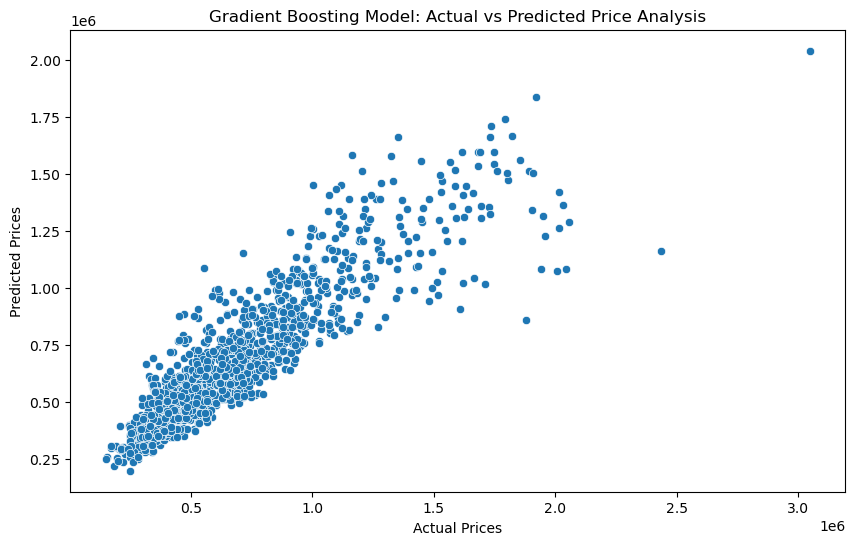

In [54]:
# Visualization of Actual vs Predicted price
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test.values.ravel(),y=y_pred_gbr)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Gradient Boosting Model: Actual vs Predicted Price Analysis')
plt.show()

# Comparision of models based on Accuracy

In [55]:
data = {'models':['Linear Regression', 'Random Forest', 'XG-Boost', 'Gradient Boosting',],
        'model_acc' :[r2_score_lr,r2_score_rfm,r2_score_xgb,r2_score_gbr]}
df = pd.DataFrame(data)
# Sort the df in descending order
df.sort_values(by='model_acc',ascending=False)

,models,model_acc
2,XG-Boost,0.828920
1,Random Forest,0.810677
3,Gradient Boosting,0.794615
0,Linear Regression,0.767964


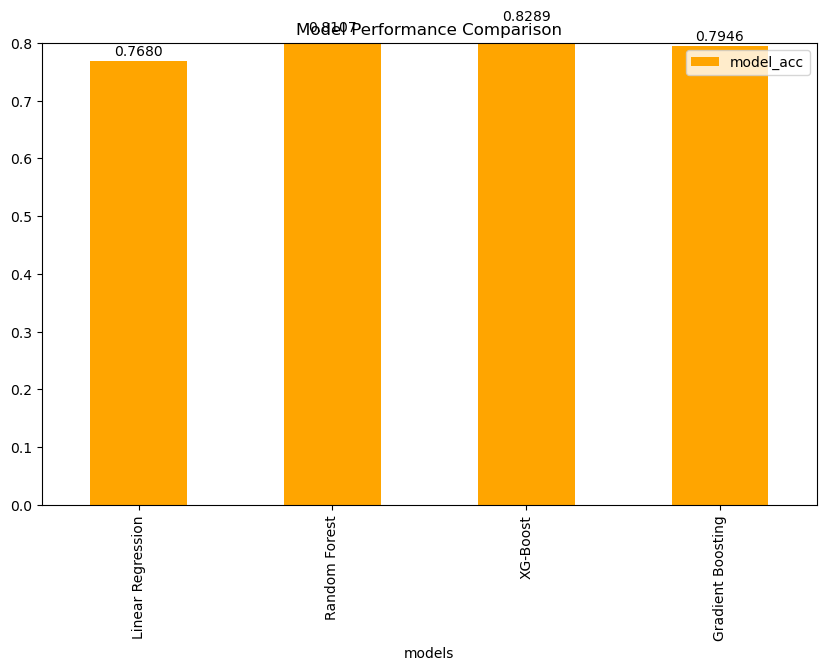

In [56]:
# Plotting the models based on accuracy
ax1 = df.plot(kind='bar', x='models',y='model_acc',figsize=(10,6),color='orange')
ax1.set_title('Model Performance Comparison')
for i, v in enumerate(df['model_acc']):
    ax1.text(i, v + 0.01, f'{v:.4f}',ha='center')
ax1.set_ylim(0,0.8) 
plt.show()

# Hyperparameter Tuning For Best model

In [57]:
from sklearn.model_selection import RandomizedSearchCV

xgb = XGBRegressor(random_state=100)

params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

random_search = RandomizedSearchCV(estimator=xgb,param_distributions=params,n_iter=20,cv=5,scoring='r2',random_state=100,n_jobs=-1)

random_search.fit(x_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9,
                                                             1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 4, 5, 6, 8],
                                        'n_estimators': [100, 200, 300, 500],
                                        'subsample': [0.7, 0.8, 0.9, 1.0]},
                   random_state=100, scoring='r2')

In [58]:
# Best parameters
print('Best parameters:',random_search.best_params_)
# Best model
best_xgb = random_search.best_estimator_

Best parameters: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [59]:
# Predicting with best model parameters
y_pred = best_xgb.predict(x_test)

In [60]:
# Evaluation
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2:", r2_score(y_test, y_pred))

MSE: 21526937600.0
RMSE: 146720.61068575198
R2: 0.8323521018028259


In [61]:
import pickle
file='Cars_project.pkl'
pickle.dump(best_xgb,open('Cars_project.pkl','wb'))
pickle.dump(scaler, open('scaler.pkl','wb'))
pickle.dump(features.columns.tolist(),open('feature_columns.pkl','wb'))